
Memuat dataset...


Model berhasil dibangun! Memulai proses training...
Epoch 1/100


25/25 [==============================] - 22s 249ms/step - loss: 1.1021 - property_regression_loss: 0.6488 - class_prediction_loss: 0.9066 - property_regression_mae: 0.6434 - class_prediction_accuracy: 0.5838 - val_loss: 1.7097 - val_property_regression_loss: 1.0214 - val_class_prediction_loss: 1.3766 - val_property_regression_mae: 0.8498 - val_class_prediction_accuracy: 0.2500
Epoch 2/100
25/25 [==============================] - 3s 106ms/step - loss: 0.6108 - property_regression_loss: 0.3358 - class_prediction_loss: 0.5499 - property_regression_mae: 0.4558 - class_prediction_accuracy: 0.7663 - val_loss: 1.7067 - val_property_regression_loss: 1.0234 - val_class_prediction_loss: 1.3665 - val_property_regression_mae: 0.8508 - val_class_prediction_accuracy: 0.2500
Epoch 3/100
25/25 [==============================] - 3s 120ms/step - loss: 0.5151 - property_regression_loss: 0.2993 - class_prediction_loss: 

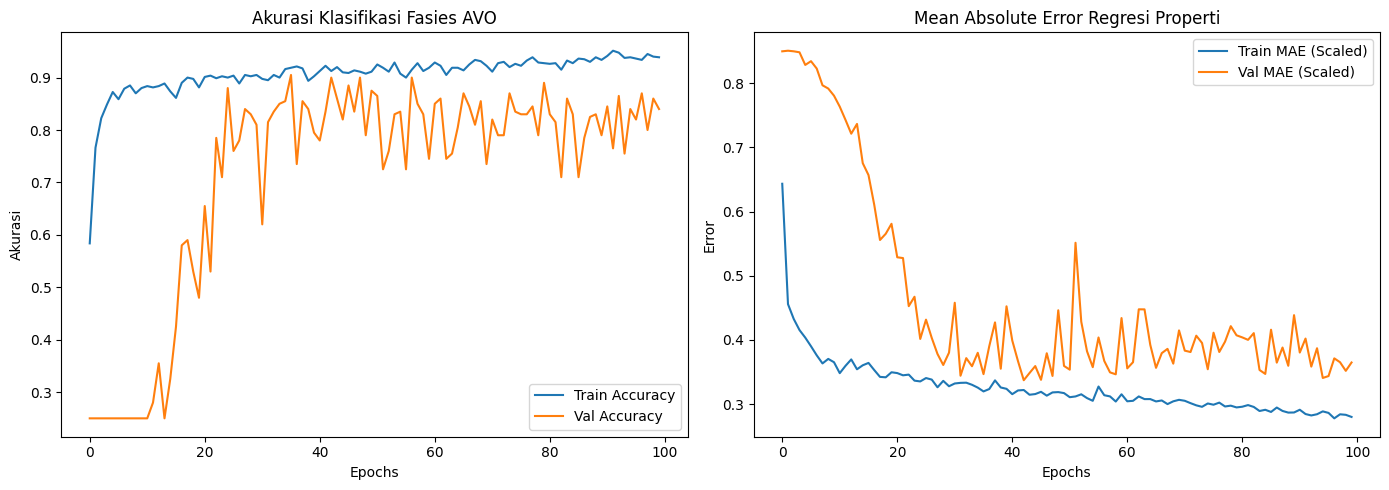

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# ==========================================
# 1. MEMUAT DAN MEMPERSIAPKAN DATA
# ==========================================
print("Memuat dataset...")
data_dir = "./seismic_avo_dataset"
X = np.load(f"{data_dir}/X_gathers.npy")        
y_reg = np.load(f"{data_dir}/y_properties.npy") 
y_clf = np.load(f"{data_dir}/y_labels.npy")     

X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

scaler = StandardScaler()
y_reg_train_scaled = scaler.fit_transform(y_reg_train)
y_reg_test_scaled = scaler.transform(y_reg_test)

# ==========================================
# 2. MEMBANGUN ARSITEKTUR MULTI-TASK BiLSTM
# ==========================================
def build_multitask_bilstm(time_steps, features):
    inputs = Input(shape=(time_steps, features), name='seismic_gather_input')
    
    x = Bidirectional(LSTM(64, return_sequences=True))(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    
    x = Bidirectional(LSTM(32, return_sequences=False))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    
    reg_branch = Dense(32, activation='relu')(x)
    reg_branch = Dense(16, activation='relu')(reg_branch)
    reg_output = Dense(3, activation='linear', name='property_regression')(reg_branch) 
    
    clf_branch = Dense(32, activation='relu')(x)
    clf_output = Dense(4, activation='softmax', name='class_prediction')(clf_branch)
    
    model = Model(inputs=inputs, outputs=[reg_output, clf_output], name="Seismic_MTL_BiLSTM")
    return model

time_steps = X_train.shape[1] 
features = X_train.shape[2]   
model = build_multitask_bilstm(time_steps, features)

# ==========================================
# 3. KOMPILASI MODEL
# ==========================================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss={'property_regression': 'mse', 'class_prediction': 'sparse_categorical_crossentropy'},
    loss_weights={'property_regression': 1.0, 'class_prediction': 0.5},
    metrics={'property_regression': 'mae', 'class_prediction': 'accuracy'}
)

print("\nModel berhasil dibangun! Memulai proses training...")

# ==========================================
# 4. PROSES TRAINING (PELATIHAN)
# ==========================================
history = model.fit(
    X_train, 
    {'property_regression': y_reg_train_scaled, 'class_prediction': y_clf_train},
    validation_data=(
        X_test, 
        {'property_regression': y_reg_test_scaled, 'class_prediction': y_clf_test}
    ),
    epochs=100,
    batch_size=32,
    verbose=1
)

# ==========================================
# 5. VISUALISASI HASIL
# ==========================================
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(history.history['class_prediction_accuracy'], label='Train Accuracy')
axs[0].plot(history.history['val_class_prediction_accuracy'], label='Val Accuracy')
axs[0].set_title('Akurasi Klasifikasi Fasies AVO')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Akurasi')
axs[0].legend()

axs[1].plot(history.history['property_regression_mae'], label='Train MAE (Scaled)')
axs[1].plot(history.history['val_property_regression_mae'], label='Val MAE (Scaled)')
axs[1].set_title('Mean Absolute Error Regresi Properti')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Error')
axs[1].legend()

plt.tight_layout()
plt.show()

--- Menggenerasi Dataset Pelatihan ---

--- Melatih Model ---
Training selesai.

--- Blind Test Skenario Baru ---
1/1 [==============================] - 1s 1s/step

--- Menyimpan Blind Dataset ---
Data pengujian berhasil diamankan secara permanen di direktori: ./seismic_blind_test_dataset/
File yang tersimpan:
1. X_blind_gathers.npy
2. y_blind_properties_actual.npy
3. y_blind_classes_actual.npy


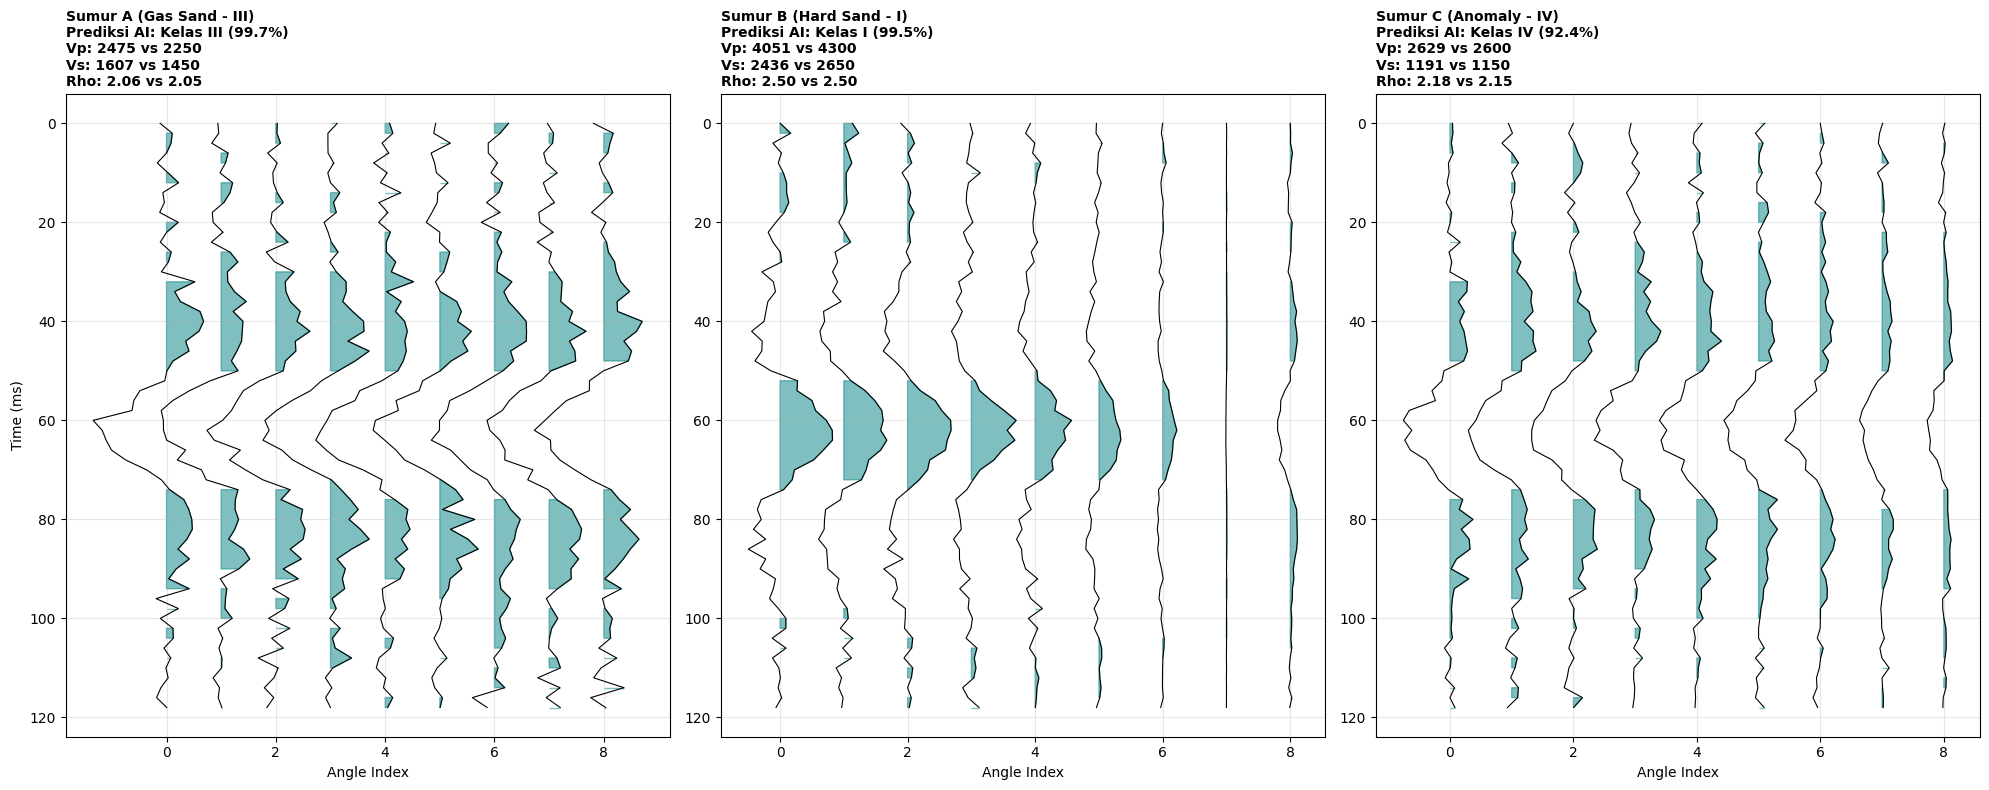

In [8]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import os

# ==========================================
# 1. FUNGSI FISIKA DASAR & PEMODELAN GATHER
# ==========================================
def shuey_2term(vp1, vs1, rho1, vp2, vs2, rho2, angles_deg):
    dvp = vp2 - vp1; dvs = vs2 - vs1; drho = rho2 - rho1
    vp_avg = (vp1 + vp2) / 2.0; vs_avg = (vs1 + vs2) / 2.0; rho_avg = (rho1 + rho2) / 2.0
    A = 0.5 * (dvp / vp_avg + drho / rho_avg)
    B = 0.5 * (dvp / vp_avg) - 2.0 * (vs_avg / vp_avg)**2 * (drho / rho_avg + 2.0 * dvs / vs_avg)
    theta_rad = np.radians(angles_deg)
    R_theta = A + B * np.sin(theta_rad)**2
    return R_theta, A, B

def ricker_wavelet(freq, length, dt):
    t = np.arange(-length/2, (length)/2, dt)
    y = (1.0 - 2.0 * (np.pi**2) * (freq**2) * (t**2)) * np.exp(-(np.pi**2) * (freq**2) * (t**2))
    return t, y

def add_noise(signal, snr_db):
    signal_power = np.mean(signal**2)
    if signal_power == 0: return signal
    noise_power = signal_power / (10**(snr_db / 10))
    noise = np.random.normal(0, np.sqrt(noise_power), signal.shape)
    return signal + noise

# ==========================================
# 2. GENERASI DATASET (1000 SAMPEL, 4 KELAS AVO)
# ==========================================
print("--- Menggenerasi Dataset Pelatihan ---")
avo_classes = {
    "Kelas I":   {"vp1": 3300, "vs1": 1700, "rho1": 2.35, "vp2": 4000, "vs2": 2400, "rho2": 2.40},
    "Kelas II":  {"vp1": 3000, "vs1": 1500, "rho1": 2.40, "vp2": 3100, "vs2": 1900, "rho2": 2.30},
    "Kelas III": {"vp1": 3000, "vs1": 1500, "rho1": 2.40, "vp2": 2400, "vs2": 1600, "rho2": 2.10},
    "Kelas IV":  {"vp1": 3200, "vs1": 1600, "rho1": 2.40, "vp2": 2500, "vs2": 1100, "rho2": 2.10}
}

angles = np.arange(0, 45, 5); dt = 0.002; n_samples = 60
reflector_index = int(n_samples / 2)
_, wavelet = ricker_wavelet(20.0, 0.1, dt)

X_list, y_reg_list, y_clf_list = [], [], []

for class_id, (name, props) in enumerate(avo_classes.items()):
    for _ in range(250): # 250 sampel per kelas
        # Variasi Monte Carlo +/- 5%
        p = {k: np.random.normal(v, v*0.05) for k, v in props.items()}
        R_t, _, _ = shuey_2term(p['vp1'], p['vs1'], p['rho1'], p['vp2'], p['vs2'], p['rho2'], angles)
        
        gather = np.zeros((n_samples, len(angles)))
        for i, r in enumerate(R_t):
            rc = np.zeros(n_samples); rc[reflector_index] = r
            trace = np.convolve(rc, wavelet, mode='same')
            gather[:, i] = add_noise(trace, np.random.uniform(8, 15))
        
        X_list.append(gather); y_reg_list.append([p['vp2'], p['vs2'], p['rho2']]); y_clf_list.append(class_id)

X = np.array(X_list); y_reg = np.array(y_reg_list); y_clf = np.array(y_clf_list)

# Preprocessing
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)
scaler = StandardScaler()
y_reg_train_s = scaler.fit_transform(y_reg_train)
y_reg_test_s = scaler.transform(y_reg_test)

# ==========================================
# 3. MEMBANGUN & MELATIH MULTI-TASK BiLSTM
# ==========================================
def build_model(time_steps, features):
    inputs = Input(shape=(time_steps, features))
    x = Bidirectional(LSTM(64, return_sequences=True))(inputs)
    x = BatchNormalization()(x)
    x = Bidirectional(LSTM(32, return_sequences=False))(x)
    x = Dropout(0.2)(x)
    
    # Branch Regresi
    reg = Dense(32, activation='relu')(x)
    reg_out = Dense(3, activation='linear', name='reg_out')(reg)
    
    # Branch Klasifikasi
    clf = Dense(32, activation='relu')(x)
    clf_out = Dense(4, activation='softmax', name='clf_out')(clf)
    
    return Model(inputs=inputs, outputs=[reg_out, clf_out])

model = build_model(X_train.shape[1], X_train.shape[2])
model.compile(optimizer='adam', 
              loss={'reg_out': 'mse', 'clf_out': 'sparse_categorical_crossentropy'},
              loss_weights={'reg_out': 1.0, 'clf_out': 0.5},
              metrics={'reg_out': 'mae', 'clf_out': 'accuracy'})

print("\n--- Melatih Model ---")
history = model.fit(X_train, {'reg_out': y_reg_train_s, 'clf_out': y_clf_train},
                    validation_data=(X_test, {'reg_out': y_reg_test_s, 'clf_out': y_clf_test}),
                    epochs=60, batch_size=32, verbose=0)
print("Training selesai.")

# ==========================================
# 4. PENGUJIAN PADA BLIND DATASET (SUMUR BARU)
# ==========================================
print("\n--- Blind Test Skenario Baru ---")
blind_scenarios = [
    {"nama": "Sumur A (Gas Sand - III)", "vp1": 3000, "vs1": 1500, "rho1": 2.4, "vp2": 2250, "vs2": 1450, "rho2": 2.05},
    {"nama": "Sumur B (Hard Sand - I)", "vp1": 3300, "vs1": 1700, "rho1": 2.4, "vp2": 4300, "vs2": 2650, "rho2": 2.50},
    {"nama": "Sumur C (Anomaly - IV)", "vp1": 3100, "vs1": 1550, "rho1": 2.4, "vp2": 2600, "vs2": 1150, "rho2": 2.15}
]

X_blind, y_blind_actual = [], []
for s in blind_scenarios:
    R_t, _, _ = shuey_2term(s['vp1'], s['vs1'], s['rho1'], s['vp2'], s['vs2'], s['rho2'], angles)
    g = np.zeros((n_samples, len(angles)))
    for i, r in enumerate(R_t):
        rc = np.zeros(n_samples); rc[reflector_index] = r
        g[:, i] = add_noise(np.convolve(rc, wavelet, mode='same'), 10.0)
    X_blind.append(g); y_blind_actual.append([s['vp2'], s['vs2'], s['rho2']])

X_blind = np.array(X_blind)
pred_reg_s, pred_clf_p = model.predict(X_blind)
pred_reg = scaler.inverse_transform(pred_reg_s)
pred_clf = np.argmax(pred_clf_p, axis=1)

# ==========================================
# 5. VISUALISASI AKHIR
# ==========================================
fig, axs = plt.subplots(1, 3, figsize=(20, 8))
time_axis = np.arange(n_samples) * dt * 1000
labels = {0: "Kelas I", 1: "Kelas II", 2: "Kelas III", 3: "Kelas IV"}

for i, s in enumerate(blind_scenarios):
    ax = axs[i]
    for j, angle in enumerate(angles):
        trace = X_blind[i, :, j] * 5 + j
        ax.plot(trace, time_axis, color='black', lw=0.8)
        ax.fill_betweenx(time_axis, j, trace, where=(trace > j), color='teal', alpha=0.5)
    
    ax.invert_yaxis(); ax.set_xlabel("Angle Index"); ax.set_ylabel("Time (ms)" if i==0 else "")
    info = f"{s['nama']}\nPrediksi AI: {labels[pred_clf[i]]} ({np.max(pred_clf_p[i])*100:.1f}%)\n"
    info += f"Vp: {pred_reg[i,0]:.0f} vs {s['vp2']:.0f}\nVs: {pred_reg[i,1]:.0f} vs {s['vs2']:.0f}\nRho: {pred_reg[i,2]:.2f} vs {s['rho2']:.2f}"
    ax.set_title(info, fontsize=10, fontweight='bold', loc='left')
    ax.grid(True, alpha=0.3)
    
# ==========================================
# 6. PENYIMPANAN BLIND DATASET
# ==========================================
print("\n--- Menyimpan Blind Dataset ---")

# Buat direktori baru khusus untuk data pengujian agar tidak tercampur dengan data training
blind_save_dir = "./seismic_blind_test_dataset"
os.makedirs(blind_save_dir, exist_ok=True)

# Simpan data input (Angle Gather)
np.save(f"{blind_save_dir}/X_blind_gathers.npy", X_blind)

# Simpan data target aktual (Nilai Vp, Vs, Rho untuk referensi)
np.save(f"{blind_save_dir}/y_blind_properties_actual.npy", np.array(y_blind_actual))

# (Opsional) Simpan ID kelas aktual jika Anda juga ingin mengevaluasi klasifikasi di masa depan
# Sumur A (Kelas III=2), Sumur B (Kelas I=0), Sumur C (Kelas IV=3)
y_blind_kelas_actual = np.array([2, 0, 3]) 
np.save(f"{blind_save_dir}/y_blind_classes_actual.npy", y_blind_kelas_actual)

print(f"Data pengujian berhasil diamankan secara permanen di direktori: {blind_save_dir}/")
print("File yang tersimpan:")
print("1. X_blind_gathers.npy")
print("2. y_blind_properties_actual.npy")
print("3. y_blind_classes_actual.npy")
plt.tight_layout()
plt.show()